# Which Statistics Drive Winning in European Football? – Modeling & Evaluation

This notebook aims to build and evaluate machine learning models to predict match outcomes in European football using the feature-engineered match statistics created in the previous notebook. A binary target variable representing whether the home team won the match is used as the outcome of interest.

The following steps are performed in this notebook:

- **Features**: Differential match statistics such as expected goals difference, possession difference, shots on target difference, corners difference, and passes difference  
- **Target Variable**: Match outcome (home win vs. non-home win)  
- **Models**: Baseline and comparative classification models  
- **Evaluation**: Model performance assessed using standard classification metrics  

The output of this notebook is an evaluation of how well match-level performance statistics explain winning outcomes, along with insights into which features are most influential in predicting match results across Europe’s top football leagues.


In [87]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load feature-engineered dataset
df = pd.read_csv("../data/football_2023_2024_features.csv")

# Remove rows with missing values
df = df.dropna()

print("Shape:", df.shape)
df.head()


Shape: (989, 20)


,League,home_goals,away_goals,season_year,xg_home,xg_away,possession_home,possession_away,shots_on_target_home,shots_on_target_away,corners_home,corners_away,passes_home,passes_away,home_win,xg_diff,possession_diff,shots_on_target_diff,corners_diff,passes_diff
0,Bundesliga,0,4,2023/2024,1.94,2.76,42.0,58.0,5.0,8.0,14.0,8.0,363.0,703.0,0,-0.82,-16.0,-3.0,6.0,-340.0
1,Bundesliga,0,3,2023/2024,1.32,2.25,55.0,45.0,3.0,8.0,7.0,8.0,482.0,313.0,0,-0.93,10.0,-5.0,-1.0,169.0
2,Bundesliga,2,1,2023/2024,2.86,0.77,62.0,38.0,8.0,2.0,5.0,4.0,728.0,382.0,1,2.09,24.0,6.0,1.0,346.0
3,Bundesliga,4,0,2023/2024,2.83,0.42,71.0,29.0,10.0,1.0,7.0,3.0,727.0,258.0,1,2.41,42.0,9.0,4.0,469.0
4,Bundesliga,2,2,2023/2024,2.02,1.73,46.0,54.0,6.0,5.0,8.0,3.0,432.0,520.0,0,0.29,-8.0,1.0,5.0,-88.0


In [88]:
# Defining the feature matrix (X) and Target (y)

X = df[
    ["xg_diff", "possession_diff", "shots_on_target_diff",
     "corners_diff", "passes_diff"]
]
y = df["home_win"]

print("X Shape: ", X.shape)
print("y Shape: ", y.shape)

X Shape:  (989, 5)
y Shape:  (989,)


In [89]:
# Train test split (75% training, 25% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Sanity checks
print("Total rows:", len(X))
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training %:", len(X_train) / len(X))
print("Testing %:", len(X_test) / len(X))

# Checking how balanced the class is
print("Overall home win rate:", y.mean())
print("Train home win rate:", y_train.mean())
print("Test home win rate:", y_test.mean())


Total rows: 989
Training rows: 741
Testing rows: 248
Training %: 0.7492416582406471
Testing %: 0.25075834175935285
Overall home win rate: 0.43377148634984836
Train home win rate: 0.4331983805668016
Test home win rate: 0.43548387096774194


In [90]:
from sklearn.linear_model import LogisticRegression

# Initialize baseline logistic regression model
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42     
)

In [91]:
# Train the model on the training data
log_reg.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

This section generates predictions from the trained logistic regression model and evaluates baseline performance using standard classification metrics.

In [92]:
# Generate predictions on the test set

y_pred = log_reg.predict(X_test)
y_proba = log_reg.predict_proba(X_test)[:, 1]

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7701612903225806
ROC-AUC: 0.8294312169312169

Confusion Matrix:
[[103  37]
 [ 20  88]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.74      0.78       140
           1       0.70      0.81      0.76       108

    accuracy                           0.77       248
   macro avg       0.77      0.78      0.77       248
weighted avg       0.78      0.77      0.77       248



## Feature Importance Interpretation

The largest positive coefficients indicate which match statistics most strongly increase the probability of a home win.

The largest negative coefficients indicate which statistics are associated with the away team having an advantage.

Features with larger absolute coefficient values have a stronger impact on the model's predictions.

In [93]:
leagues = {
    "Premier League": df[df["League"] == "Premier-league"],
    "Bundesliga": df[df["League"] == "Bundesliga"],
    "Ligue 1": df[df["League"] == "Ligue-1"]
}

In [94]:
from sklearn.metrics import accuracy_score, roc_auc_score

def train_log_reg(df_subset):
    X = df_subset[["xg_diff", "possession_diff", "shots_on_target_diff", "corners_diff", "passes_diff"]]
    y = df_subset["home_win"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    coef_df = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": model.coef_[0]
    })

    coef_df["Absolute_Coefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values(by="Absolute_Coefficient", ascending=False)

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    return coef_df, acc, auc

In [95]:
results = {}

for league_name, df_league in leagues.items():
    coef_df, acc, auc = train_log_reg(df_league)
    results[league_name] = {
        "coefficients": coef_df,
        "accuracy": acc,
        "auc": auc
    }

In [97]:
for league_name, result in results.items():
    print(f"{league_name}")
    print(f"Accuracy: {result['accuracy']:.3f}")
    print(f"ROC-AUC: {result['auc']:.3f}")
    print(result["coefficients"])

Premier League
Accuracy: 0.758
ROC-AUC: 0.839
                Feature  Coefficient  Absolute_Coefficient
0               xg_diff     0.856064              0.856064
2  shots_on_target_diff     0.253908              0.253908
3          corners_diff    -0.092438              0.092438
1       possession_diff    -0.088808              0.088808
4           passes_diff     0.009335              0.009335
Bundesliga
Accuracy: 0.697
ROC-AUC: 0.788
                Feature  Coefficient  Absolute_Coefficient
0               xg_diff     0.744653              0.744653
2  shots_on_target_diff     0.216061              0.216061
3          corners_diff    -0.147518              0.147518
1       possession_diff     0.009458              0.009458
4           passes_diff    -0.001435              0.001435
Ligue 1
Accuracy: 0.805
ROC-AUC: 0.888
                Feature  Coefficient  Absolute_Coefficient
0               xg_diff     1.011965              1.011965
2  shots_on_target_diff     0.261340           

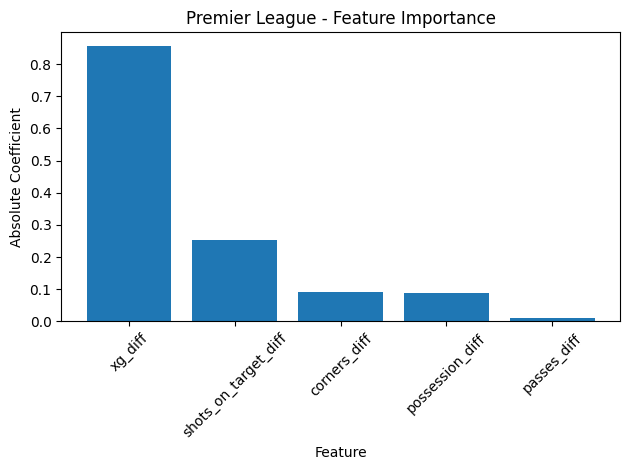

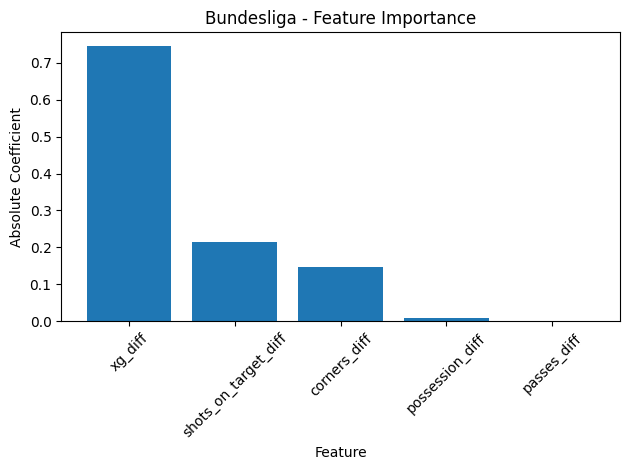

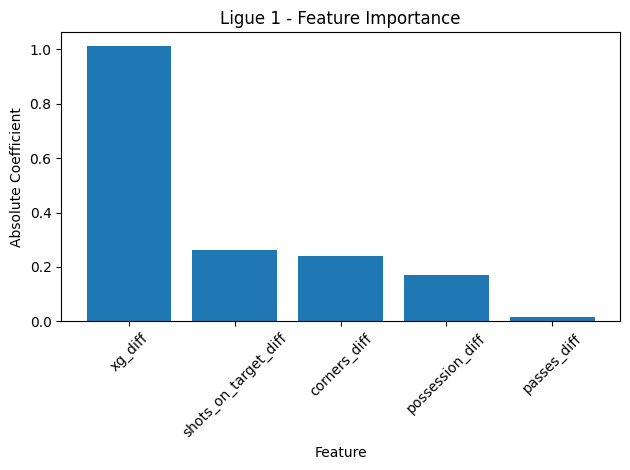

In [ ]:
import matplotlib.pyplot as plt

for league_name, result in results.items():
    coef_df = result["coefficients"]

    plt.figure()
    plt.bar(coef_df["Feature"], coef_df["Absolute_Coefficient"])
    plt.title(f"{league_name} - Feature Importance")
    plt.xlabel("Feature")
    plt.ylabel("Absolute Coefficient")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

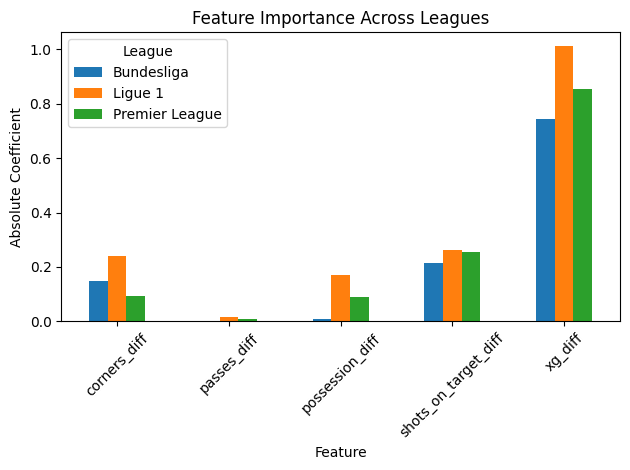

In [104]:
import pandas as pd

combined = []

for league_name, result in results.items():
    temp = result["coefficients"].copy()
    temp["League"] = league_name
    combined.append(temp)

combined_df = pd.concat(combined)

pivot_df = combined_df.pivot(index="Feature", columns="League", values="Absolute_Coefficient")

pivot_df.plot(kind="bar")
plt.title("Feature Importance Across Leagues")
plt.ylabel("Absolute Coefficient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()